###Import The Necessary Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
from sklearn.utils import shuffle
import warnings
warnings.filterwarnings("ignore")

###1. Data Undersanding

In [ ]:
#load the dataset
df = pd.read_csv("/content/archive.zip")
df.head()

,Season,Age,Childish diseases,Accident or serious trauma,Surgical intervention,High fevers in the last year,Frequency of alcohol consumption,Smoking habit,Number of hours spent sitting per day,Diagnosis
0,spring,30,no,yes,yes,more than 3 months ago,once a week,occasional,16,Normal
1,spring,35,yes,no,yes,more than 3 months ago,once a week,daily,6,Altered
2,spring,27,yes,no,no,more than 3 months ago,hardly ever or never,never,9,Normal
3,spring,32,no,yes,yes,more than 3 months ago,hardly ever or never,never,7,Normal
4,spring,30,yes,yes,no,more than 3 months ago,once a week,never,9,Altered


In [ ]:
#check the type of df
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
#convert df to a dataframe
df = pd.DataFrame(df)
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
#check the shape of the dataset
df.shape

(100, 10)

In [ ]:
#check the info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Season                                 100 non-null    object
 1   Age                                    100 non-null    int64 
 2   Childish diseases                      100 non-null    object
 3   Accident or serious trauma             100 non-null    object
 4   Surgical intervention                  100 non-null    object
 5   High fevers in the last year           100 non-null    object
 6   Frequency of alcohol consumption       100 non-null    object
 7   Smoking habit                          100 non-null    object
 8   Number of hours spent sitting per day  100 non-null    int64 
 9   Diagnosis                              100 non-null    object
dtypes: int64(2), object(8)
memory usage: 7.9+ KB


In [ ]:
#check the unique values
df.nunique()

,0
Season,4
Age,10
Childish diseases,2
Accident or serious trauma,2
Surgical intervention,2
High fevers in the last year,3
Frequency of alcohol consumption,5
Smoking habit,3
Number of hours spent sitting per day,14
Diagnosis,2


In [ ]:
#check the statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,100.0,30.11,2.246861,27.0,28.0,30.0,32.0,36.0
Number of hours spent sitting per day,100.0,10.80,33.616975,1.0,5.0,7.0,9.0,342.0


###2. Data Cleaning

In [ ]:
#check for duplicated values
df.duplicated().sum()

np.int64(1)

In [ ]:
#drop the duplicated value
df.drop_duplicates(inplace=True)
#check if there are still duplicated values
df.duplicated().sum()

np.int64(0)

In [ ]:
#check for missing values
df.isnull().sum()

,0
Season,0
Age,0
Childish diseases,0
Accident or serious trauma,0
Surgical intervention,0
High fevers in the last year,0
Frequency of alcohol consumption,0
Smoking habit,0
Number of hours spent sitting per day,0
Diagnosis,0


In [ ]:
#create a numerical column
num_cols = ["Age", "Number of hours spent sitting per day"]
num_cols

['Age', 'Number of hours spent sitting per day']

In [ ]:
#create a categorical column
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols

Index(['Season', 'Childish diseases', 'Accident or serious trauma',
       'Surgical intervention', 'High fevers in the last year',
       'Frequency of alcohol consumption', 'Smoking habit', 'Diagnosis'],
      dtype='object')

Dataset before outlier removal: 99, Dataset after outlier removal: 99


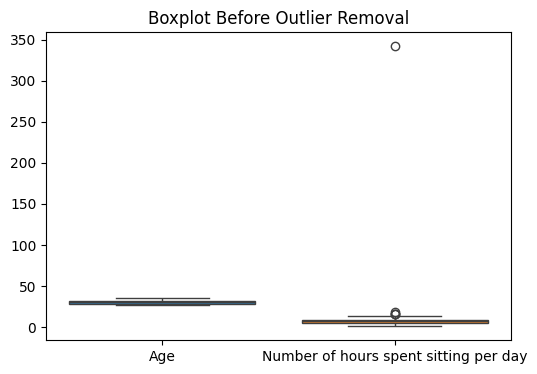

In [ ]:
#boxplot to visualize presence of outliers
plt.figure(figsize=(6, 4))
sns.boxplot(data=df[num_cols])
plt.title("Boxplot Before Outlier Removal")
plt.show()

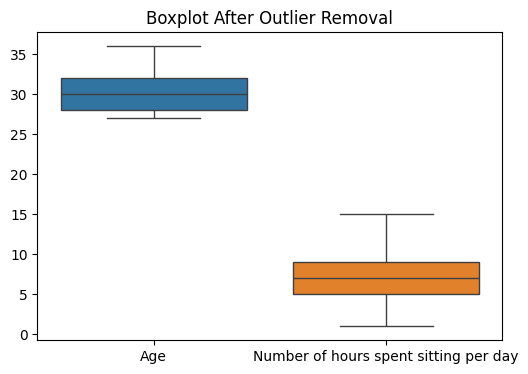

In [ ]:
#check for outliers
zscore = stats.zscore(df[num_cols])
abs_zscore = np.abs(zscore)
filtered_entities = (abs_zscore > 3)
df_no_outliers = df[filtered_entities]
print(f"Dataset before outlier removal: {len(df)}, Dataset after outlier removal: {len(df_no_outliers)}")

#define Q1, Q2 and IQR
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

#define lower and upper boundaries
lower_boundary = Q1 - 1.5 * IQR
upper_boundary = Q3 + 1.5 * IQR

#apply clipping
df[num_cols] = df[num_cols].clip(lower_boundary, upper_boundary, axis=1)

#visualize absence of outliers
plt.figure(figsize=(6, 4))
sns.boxplot(data=df[num_cols])
plt.title("Boxplot After Outlier Removal")
plt.show()

###3. Data Preprocessing

In [ ]:
#performing normalization
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
df.head()

,Season,Age,Childish diseases,Accident or serious trauma,Surgical intervention,High fevers in the last year,Frequency of alcohol consumption,Smoking habit,Number of hours spent sitting per day,Diagnosis
0,spring,0.333333,no,yes,yes,more than 3 months ago,once a week,occasional,1.000000,Normal
1,spring,0.888889,yes,no,yes,more than 3 months ago,once a week,daily,0.357143,Altered
2,spring,0.000000,yes,no,no,more than 3 months ago,hardly ever or never,never,0.571429,Normal
3,spring,0.555556,no,yes,yes,more than 3 months ago,hardly ever or never,never,0.428571,Normal
4,spring,0.333333,yes,yes,no,more than 3 months ago,once a week,never,0.571429,Altered


In [ ]:
#performing labelencoding
encoder = LabelEncoder()
for cols in cat_cols:
  df[cols] = encoder.fit_transform(df[cols])
df.head()

,Season,Age,Childish diseases,Accident or serious trauma,Surgical intervention,High fevers in the last year,Frequency of alcohol consumption,Smoking habit,Number of hours spent sitting per day,Diagnosis
0,1,0.333333,0,1,1,1,2,2,1.000000,1
1,1,0.888889,1,0,1,1,2,0,0.357143,0
2,1,0.000000,1,0,0,1,1,1,0.571429,1
3,1,0.555556,0,1,1,1,1,1,0.428571,1
4,1,0.333333,1,1,0,1,2,1,0.571429,0


###4. Model Selection

In [ ]:
#choose x and y variables
x = df.drop(columns=['Diagnosis'], axis=1)
y = df['Diagnosis']

#split the dataset to train and test data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

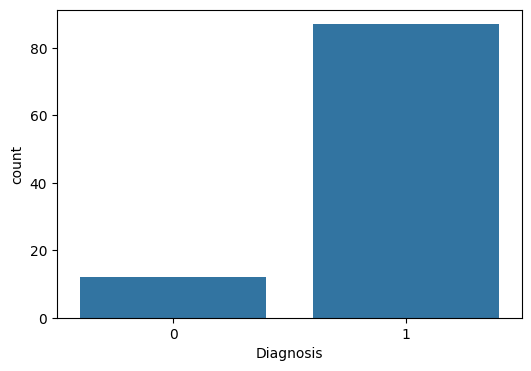

In [ ]:
#check if the target variable is balanced
plt.figure(figsize=(6, 4))
sns.countplot(x=df['Diagnosis'])
plt.show()

In [ ]:
#apply smote to the target variable
smote = SMOTE(sampling_strategy='auto', random_state=42)
x_train_resample, y_train_resample = smote.fit_resample(x_train, y_train)

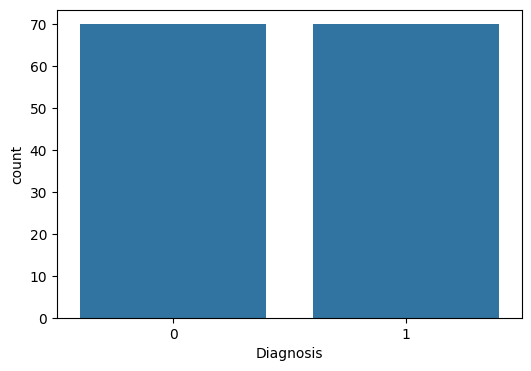

In [ ]:
#check if y is balanced
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_resample)
plt.show()

In [ ]:
#shuffle the training datasets
x_train_resample, y_train_resample = shuffle(x_train_resample, y_train_resample, random_state=42)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

In [ ]:
# convert x to a tensor
x = tf.convert_to_tensor(x_train_resample)
x.shape

TensorShape([140, 9])

In [ ]:
#convert y to a tensor
y = tf.convert_to_tensor(y_train_resample)
y = tf.reshape(y, [-1, 1])
y.shape

TensorShape([140, 1])

In [ ]:
model = Sequential(
    [

    Dense(128, input_shape=(x.shape[1],), activation='relu', kernel_initializer='he_normal'),
    Dropout(0.4),#prevents overfitting
    Dense(64, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.4),
    Dense(32, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')  # Binary classification output

    ]
)

In [ ]:
#prepare the model
model.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
#stop training when the validation loss stops improving
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

#train the model
history = model.fit(x, y, batch_size=16, epochs=50, validation_split=0.2, shuffle=True, verbose=2, callbacks=[early_stopping])
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

Epoch 1/50
7/7 - 3s - 379ms/step - accuracy: 0.5625 - loss: 0.9409 - val_accuracy: 0.6429 - val_loss: 0.6094
Epoch 2/50
7/7 - 0s - 22ms/step - accuracy: 0.5357 - loss: 0.8810 - val_accuracy: 0.8214 - val_loss: 0.5510
Epoch 3/50
7/7 - 0s - 36ms/step - accuracy: 0.6786 - loss: 0.6495 - val_accuracy: 0.8571 - val_loss: 0.5317
Epoch 4/50
7/7 - 0s - 20ms/step - accuracy: 0.7768 - loss: 0.5219 - val_accuracy: 0.8214 - val_loss: 0.5050
Epoch 5/50
7/7 - 0s - 14ms/step - accuracy: 0.7500 - loss: 0.5698 - val_accuracy: 0.8571 - val_loss: 0.4185
Epoch 6/50
7/7 - 0s - 14ms/step - accuracy: 0.7946 - loss: 0.4434 - val_accuracy: 0.8929 - val_loss: 0.3390
Epoch 7/50
7/7 - 0s - 20ms/step - accuracy: 0.8125 - loss: 0.5001 - val_accuracy: 0.8571 - val_loss: 0.3227
Epoch 8/50
7/7 - 0s - 20ms/step - accuracy: 0.8750 - loss: 0.3917 - val_accuracy: 0.9286 - val_loss: 0.2859
Epoch 9/50
7/7 - 0s - 18ms/step - accuracy: 0.7768 - loss: 0.5012 - val_accuracy: 0.8571 - val_loss: 0.3651
Epoch 10/50
7/7 - 0s - 20ms

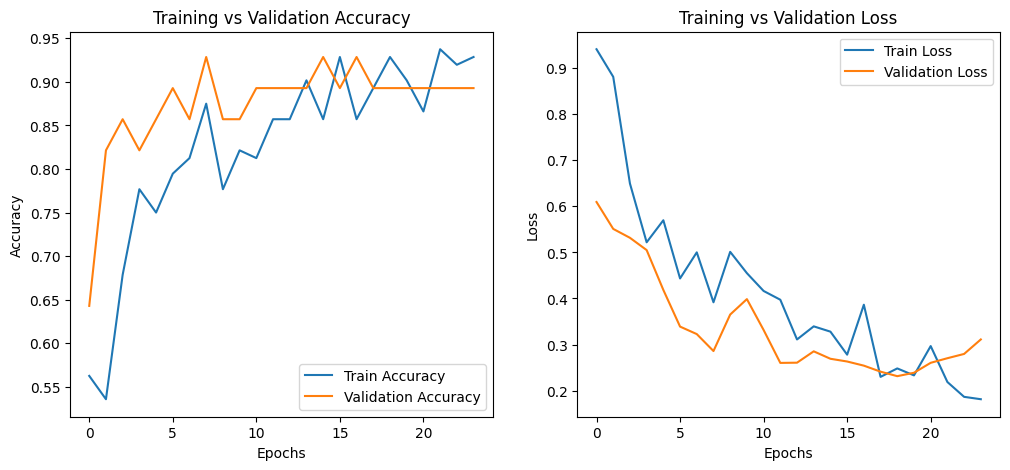

In [ ]:
# plot the training history (accuracy and loss curves) to analyze the learning behavior
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()
